# Lesson 7: Linear Algebra, Regression, and Regularization

**Probability, Statistics and Econometrics for Finance, Accounting and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, PhD

## Where this lecture fits in the seven-lecture sequence

The first six lectures developed probability, statistics, hypothesis testing, relationships among variables, time series, asset pricing, valuation, and games of chance. This final lecture provides the mathematical language used underneath many of those tools: **linear algebra**.

Linear algebra is not just an abstract mathematical topic. It is the language of:

1. portfolios and covariance matrices,
2. systems of equations,
3. least-squares regression,
4. projections and residuals,
5. polynomial features,
6. regularization,
7. cross-validation and modern predictive modeling.

By the end of the lecture, students should be able to read the main matrix formulas behind ordinary least squares, understand why regression is a projection problem, and see why Ridge, Lasso, and Elastic Net are natural extensions of least squares.

## Learning objectives

By the end of this notebook, you should be able to:

1. Define vectors, matrices, transposes, dot products, matrix products, inverses, determinants, rank, and eigenvalues.
2. Solve systems of linear equations of the form

$$
A x = b.
$$

3. Explain least squares as the problem of finding the best approximate solution to an overdetermined system.
4. Derive and compute the ordinary least squares estimator

$$
\hat{\beta} = (X'X)^{-1}X'y.
$$

5. Interpret residuals geometrically as the part of $y$ left over after projecting $y$ onto the column space of $X$.
6. Use polynomial features to fit nonlinear relationships with linear regression.
7. Explain why regularization reduces overfitting.
8. Compare Ridge, Lasso, and Elastic Net regression.
9. Use cross-validation to choose regularization parameters.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numpy.linalg import inv, solve, matrix_rank, eig
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-z2ffyblq because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


# 1. Vectors and matrices

A **vector** is an ordered list of numbers. In finance and economics, vectors commonly represent portfolios, prices, quantities, returns, or regression coefficients.

For example, a portfolio weight vector might be

$$
w =
\begin{bmatrix}
0.50 \\
0.30 \\
0.20
\end{bmatrix},
$$

meaning that 50 percent of wealth is invested in asset 1, 30 percent in asset 2, and 20 percent in asset 3.

A **matrix** is a rectangular array of numbers. Matrices are used to represent systems of equations, datasets, covariance matrices, and linear transformations:

$$
A =
\begin{bmatrix}
1 & 2 \\
3 & 4 \\
5 & 6
\end{bmatrix}.
$$

If a matrix has $m$ rows and $n$ columns, it is an $m \times n$ matrix.

In [2]:
vector = np.array([1, 2, 3])
matrix = np.array([[1, 2],
                   [3, 4],
                   [5, 6]])

print("Vector:")
print(vector)

print("\nMatrix:")
print(matrix)

print("\nVector shape:", vector.shape)
print("Matrix shape:", matrix.shape)

Vector:
[1 2 3]

Matrix:
[[1 2]
 [3 4]
 [5 6]]

Vector shape: (3,)
Matrix shape: (3, 2)


## 1.1 Transposes

The **transpose** of a matrix flips rows and columns. If $A$ is an $m \times n$ matrix, then $A'$ is an $n \times m$ matrix.

If

$$
A =
\begin{bmatrix}
1 & 2 \\
3 & 4 \\
5 & 6
\end{bmatrix},
$$

then

$$
A' =
\begin{bmatrix}
1 & 3 & 5 \\
2 & 4 & 6
\end{bmatrix}.
$$

In [3]:
transpose = matrix.T
print("Original matrix:")
print(matrix)

print("\nTranspose:")
print(transpose)

Original matrix:
[[1 2]
 [3 4]
 [5 6]]

Transpose:
[[1 3 5]
 [2 4 6]]


## 1.2 Dot products

The **dot product** of two vectors is the sum of the products of their corresponding entries:

$$
x'y = \sum_{i=1}^n x_i y_i.
$$

For example, if

$$
x =
\begin{bmatrix}
1 \\ 2 \\ 3
\end{bmatrix},
\qquad
y =
\begin{bmatrix}
4 \\ 5 \\ 6
\end{bmatrix},
$$

then

$$
x'y = 1(4) + 2(5) + 3(6) = 32.
$$

In finance, expected portfolio return is a dot product:

$$
E[R_p] = w'\mu = \sum_{i=1}^n w_i E[R_i].
$$

In [4]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

dot_product = x @ y

weights = np.array([0.5, 0.3, 0.2])
expected_returns = np.array([0.08, 0.10, 0.12])
portfolio_expected_return = weights @ expected_returns

print("Dot product x'y:", dot_product)
print("Expected portfolio return:", f"{portfolio_expected_return:.2%}")

Dot product x'y: 32
Expected portfolio return: 9.40%


## 1.3 Matrix multiplication

Matrix multiplication generalizes dot products. If $A$ is $m \times n$ and $B$ is $n \times k$, then $AB$ is $m \times k$.

The entry in row $i$ and column $j$ of $AB$ is the dot product of row $i$ of $A$ and column $j$ of $B$:

$$
(AB)_{ij} = \sum_{\ell = 1}^{n} A_{i\ell}B_{\ell j}.
$$

Matrix multiplication is usually **not commutative**:

$$
AB \neq BA.
$$

In [5]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])

B = np.array([[7, 8],
              [9, 10]])

product = A @ B

print("A:")
print(A)

print("\nB:")
print(B)

print("\nAB:")
print(product)

A:
[[1 2]
 [3 4]
 [5 6]]

B:
[[ 7  8]
 [ 9 10]]

AB:
[[ 25  28]
 [ 57  64]
 [ 89 100]]


# 2. Square matrices, inverses, determinants, rank, and eigenvalues

A **square matrix** has the same number of rows and columns.

A square matrix $A$ has an **inverse** $A^{-1}$ if

$$
A^{-1}A = AA^{-1} = I,
$$

where $I$ is the identity matrix.

An inverse allows us to solve systems of equations. If

$$
Ax = b,
$$

and $A^{-1}$ exists, then

$$
x = A^{-1}b.
$$

In numerical work, however, it is usually better to use `np.linalg.solve(A, b)` rather than explicitly computing $A^{-1}$.

In [6]:
square_matrix = np.array([[1, 2],
                          [3, 4]])

inverse = inv(square_matrix)
identity_check = square_matrix @ inverse

print("Square matrix:")
print(square_matrix)

print("\nInverse:")
print(inverse)

print("\nA @ A^{-1}:")
print(identity_check)

Square matrix:
[[1 2]
 [3 4]]

Inverse:
[[-2.   1. ]
 [ 1.5 -0.5]]

A @ A^{-1}:
[[1.0000000e+00 0.0000000e+00]
 [8.8817842e-16 1.0000000e+00]]


## 2.1 Determinant and rank

The **determinant** helps determine whether a square matrix is invertible.

For a $2 \times 2$ matrix

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix},
$$

the determinant is

$$
\det(A) = ad - bc.
$$

If

$$
\det(A) = 0,
$$

then the matrix is singular and cannot be inverted.

The **rank** of a matrix is the number of linearly independent columns. A square $n \times n$ matrix is invertible if and only if it has full rank:

$$
\text{rank}(A) = n.
$$

In [7]:
det_A = np.linalg.det(square_matrix)
rank_A = matrix_rank(square_matrix)

singular_matrix = np.array([[1, 2],
                            [2, 4]])

print("det(A):", det_A)
print("rank(A):", rank_A)

print("\nSingular matrix:")
print(singular_matrix)
print("det(singular matrix):", np.linalg.det(singular_matrix))
print("rank(singular matrix):", matrix_rank(singular_matrix))

det(A): -2.0000000000000004
rank(A): 2

Singular matrix:
[[1 2]
 [2 4]]
det(singular matrix): 0.0
rank(singular matrix): 1


## 2.2 Eigenvalues and eigenvectors

An **eigenvector** is a direction that a matrix stretches or shrinks without rotating. Formally, $v$ is an eigenvector of $A$ if

$$
Av = \lambda v,
$$

where $\lambda$ is the corresponding **eigenvalue**.

Eigenvalues are important in economics and finance because they appear in:

1. covariance-matrix decompositions,
2. principal component analysis,
3. stability of dynamic systems,
4. Markowitz portfolio analysis,
5. factor models.

In [8]:
cov_matrix = np.array([[0.04, 0.018],
                       [0.018, 0.09]])

eigenvalues, eigenvectors = eig(cov_matrix)

print("Covariance matrix:")
print(cov_matrix)

print("\nEigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Covariance matrix:
[[0.04  0.018]
 [0.018 0.09 ]]

Eigenvalues:
[0.03419416 0.09580584]

Eigenvectors:
[[-0.95171801 -0.30697366]
 [ 0.30697366 -0.95171801]]


The eigenvectors identify the main directions of variation in the two-asset return distribution. The eigenvalues measure the variance along those directions.

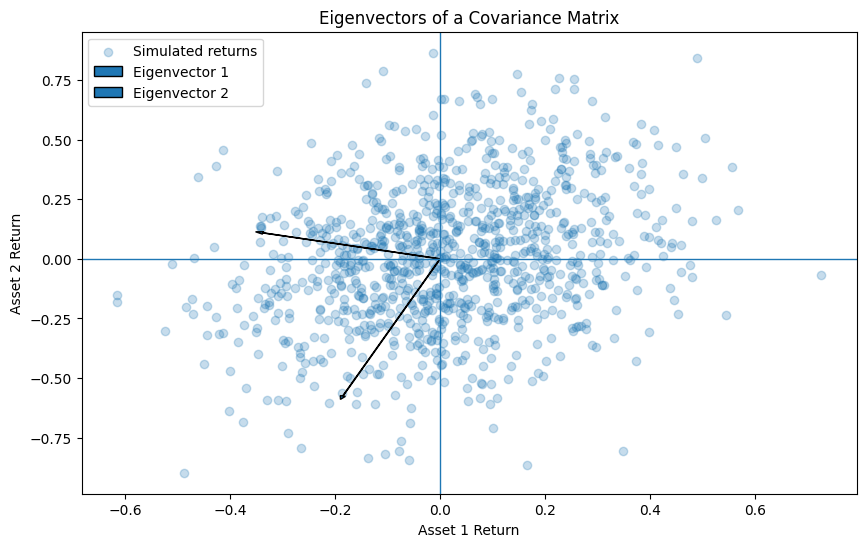

In [9]:
# Visualize covariance eigenvectors
mean = np.array([0, 0])
samples = np.random.multivariate_normal(mean, cov_matrix, size=1000)

plt.scatter(samples[:, 0], samples[:, 1], alpha=0.25, label="Simulated returns")

for i in range(len(eigenvalues)):
    direction = eigenvectors[:, i]
    length = np.sqrt(eigenvalues[i])
    plt.arrow(0, 0, 2 * length * direction[0], 2 * length * direction[1],
              head_width=0.01, length_includes_head=True, label=f"Eigenvector {i+1}")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Eigenvectors of a Covariance Matrix")
plt.xlabel("Asset 1 Return")
plt.ylabel("Asset 2 Return")
plt.legend()
plt.show()

# 3. Solving systems of equations

Consider the system

$$
\begin{aligned}
2x_1 + x_2 &= 8, \\
x_1 + 3x_2 &= 13.
\end{aligned}
$$

In matrix form,

$$
\begin{bmatrix}
2 & 1 \\
1 & 3
\end{bmatrix}
\begin{bmatrix}
x_1 \\
x_2
\end{bmatrix}
=
\begin{bmatrix}
8 \\
13
\end{bmatrix}.
$$

This is

$$
Ax = b.
$$

In [10]:
A = np.array([[2, 1],
              [1, 3]])

b = np.array([8, 13])

x_solution = solve(A, b)

print("Solution:")
print(x_solution)

print("\nCheck A @ x:")
print(A @ x_solution)

Solution:
[2.2 3.6]

Check A @ x:
[ 8. 13.]


# 4. Overdetermined systems and least squares

Many empirical problems have more equations than unknowns. Regression is the most important example.

Suppose we want to fit a line

$$
y_i = \beta_0 + \beta_1 x_i + \varepsilon_i.
$$

With many observations, we can write this as

$$
y = X\beta + \varepsilon,
$$

where

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
\vdots & \vdots \\
1 & x_n
\end{bmatrix},
\qquad
\beta =
\begin{bmatrix}
\beta_0 \\
\beta_1
\end{bmatrix}.
$$

Usually there is no exact solution to

$$
X\beta = y.
$$

Least squares chooses $\hat{\beta}$ to minimize the sum of squared residuals:

$$
\min_{\beta} \sum_{i=1}^n (y_i - x_i'\beta)^2.
$$

In matrix notation,

$$
\min_{\beta} (y - X\beta)'(y - X\beta).
$$

## 4.1 Deriving the OLS estimator

Define the residual vector

$$
e = y - X\beta.
$$

The sum of squared residuals is

$$
S(\beta) = e'e = (y - X\beta)'(y - X\beta).
$$

Expanding,

$$
S(\beta)
=
y'y - 2\beta'X'y + \beta'X'X\beta.
$$

The first-order condition is

$$
\frac{\partial S(\beta)}{\partial \beta}
=
-2X'y + 2X'X\beta
=
0.
$$

Therefore,

$$
X'X\hat{\beta} = X'y.
$$

If $X'X$ is invertible,

$$
\boxed{\hat{\beta} = (X'X)^{-1}X'y.}
$$

In [11]:
# Simulate simple linear regression data
np.random.seed(42)

n = 100
x = np.random.rand(n)
X = np.column_stack([np.ones(n), x])

true_beta = np.array([2, 3])
eps = np.random.normal(0, 0.5, size=n)
y = X @ true_beta + eps

beta_hat = inv(X.T @ X) @ X.T @ y
y_hat = X @ beta_hat
residuals = y - y_hat

print("True beta:", true_beta)
print("Estimated beta:", beta_hat)

True beta: [2 3]
Estimated beta: [2.10754808 2.77011339]


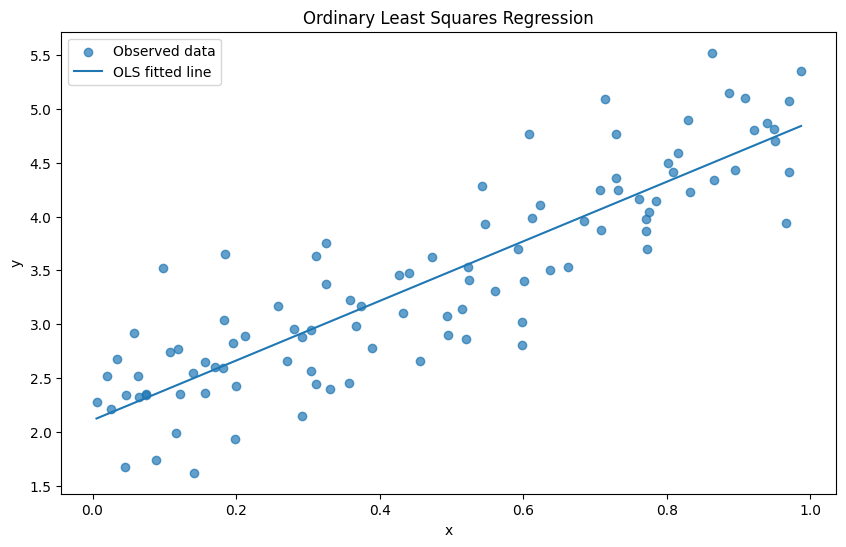

In [12]:
plt.scatter(x, y, alpha=0.7, label="Observed data")
order = np.argsort(x)
plt.plot(x[order], y_hat[order], label="OLS fitted line")
plt.title("Ordinary Least Squares Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 4.2 Regression as projection

OLS projects $y$ onto the column space of $X$.

The fitted values are

$$
\hat{y} = X\hat{\beta}.
$$

The residuals are

$$
\hat{e} = y - \hat{y}.
$$

The key geometric condition is that residuals are orthogonal to the columns of $X$:

$$
X'\hat{e} = 0.
$$

This means that after the regression line has been chosen, there is no remaining linear information in the regressors that can explain the residuals.

In [13]:
orthogonality_check = X.T @ residuals

print("X' residuals:")
print(orthogonality_check)

print("\nResidual mean:", residuals.mean())
print("Correlation between x and residuals:", np.corrcoef(x, residuals)[0, 1])

X' residuals:
[8.17124146e-14 6.56696919e-14]

Residual mean: 8.126832540256146e-16
Correlation between x and residuals: 2.0448066448426266e-15


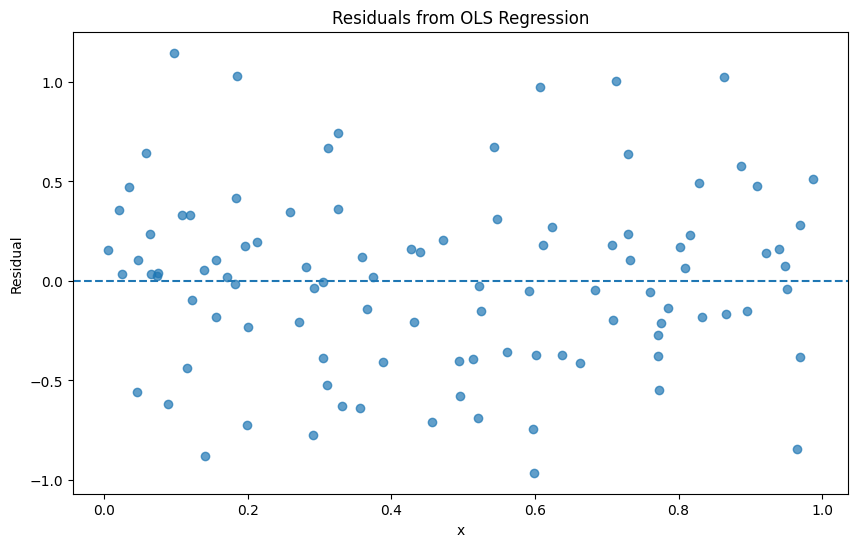

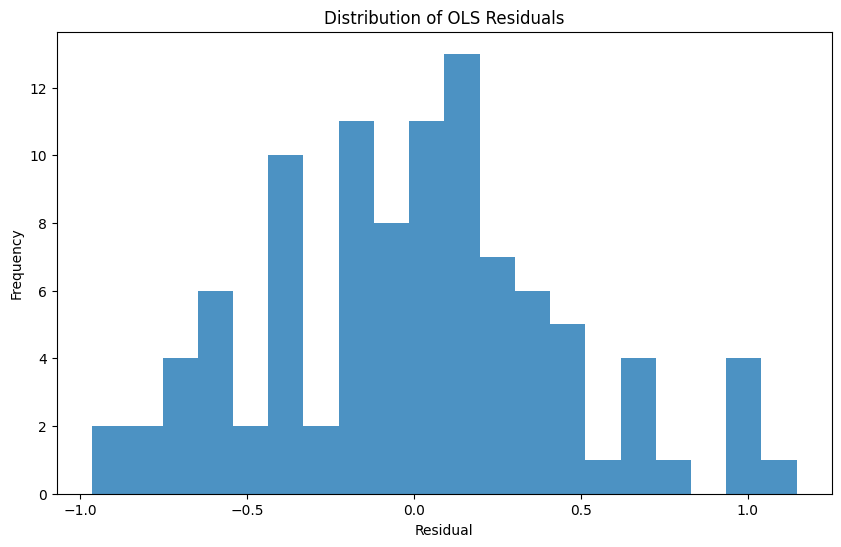

In [14]:
plt.scatter(x, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title("Residuals from OLS Regression")
plt.xlabel("x")
plt.ylabel("Residual")
plt.show()

plt.hist(residuals, bins=20, alpha=0.8)
plt.title("Distribution of OLS Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## 4.3 OLS with scikit-learn

The same regression can be estimated using `scikit-learn`. This is useful for predictive modeling workflows, pipelines, train-test splits, cross-validation, and regularization.

In [15]:
sk_model = LinearRegression()
sk_model.fit(x.reshape(-1, 1), y)

print("scikit-learn intercept:", sk_model.intercept_)
print("scikit-learn slope:", sk_model.coef_[0])

scikit-learn intercept: 2.1075480787733736
scikit-learn slope: 2.7701133864384837


# 5. Multiple regression

In multiple regression, there is more than one explanatory variable:

$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \cdots + \beta_k x_{ik} + \varepsilon_i.
$$

In matrix form, this is still

$$
y = X\beta + \varepsilon.
$$

The OLS estimator is still

$$
\hat{\beta} = (X'X)^{-1}X'y.
$$

In [16]:
np.random.seed(42)

n = 200
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
X_multi = np.column_stack([np.ones(n), x1, x2])

true_beta_multi = np.array([2, 3, -1])
y_multi = X_multi @ true_beta_multi + np.random.normal(0, 0.75, n)

beta_hat_multi = inv(X_multi.T @ X_multi) @ X_multi.T @ y_multi

print("True coefficients:", true_beta_multi)
print("Estimated coefficients:", beta_hat_multi)

True coefficients: [ 2  3 -1]
Estimated coefficients: [ 1.93273934  2.89406424 -1.01513618]


## 5.1 Goodness of fit

The coefficient of determination, $R^2$, is

$$
R^2 = 1 - \frac{\sum_i \hat{e}_i^2}{\sum_i (y_i - \bar{y})^2}.
$$

It measures the share of total variation in $y$ explained by the regression model.

In [17]:
y_multi_hat = X_multi @ beta_hat_multi
mse_multi = mean_squared_error(y_multi, y_multi_hat)
r2_multi = r2_score(y_multi, y_multi_hat)

print("MSE:", mse_multi)
print("R^2:", r2_multi)

MSE: 0.5428584780497517
R^2: 0.9342307865327907


# 6. Polynomial regression

Linear regression is linear in the coefficients, not necessarily linear in the original variable.

A polynomial regression model might be

$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \beta_3 x_i^3 + \varepsilon_i.
$$

This is still a linear regression once we define the transformed design matrix

$$
X_i =
\begin{bmatrix}
1 & x_i & x_i^2 & x_i^3
\end{bmatrix}.
$$

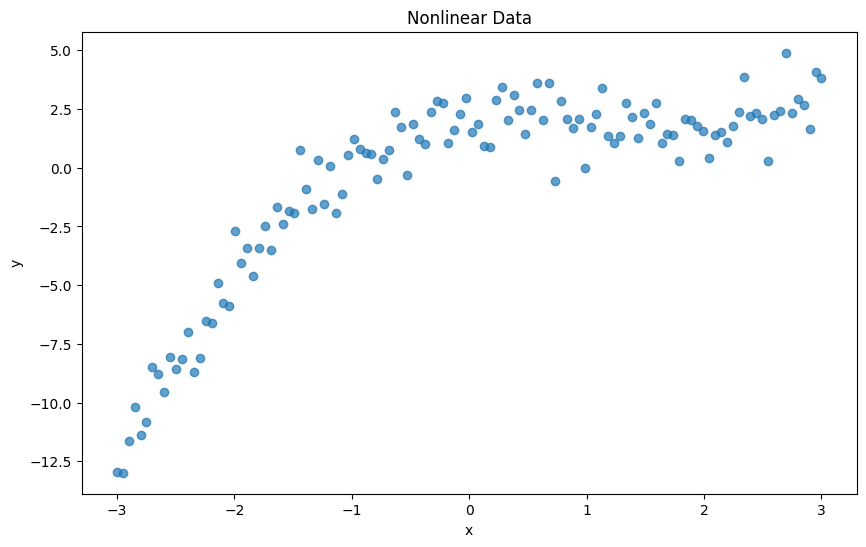

In [18]:
np.random.seed(42)

X_raw = np.linspace(-3, 3, 120).reshape(-1, 1)
y_poly = 2 + 0.5 * X_raw.ravel() - 0.8 * X_raw.ravel()**2 + 0.25 * X_raw.ravel()**3
y_poly = y_poly + np.random.normal(0, 1.0, X_raw.shape[0])

plt.scatter(X_raw, y_poly, alpha=0.7)
plt.title("Nonlinear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Polynomial feature names: ['1' 'x0' 'x0^2' 'x0^3']
Estimated coefficients: [ 1.84288077  0.64541137 -0.77444609  0.23096781]


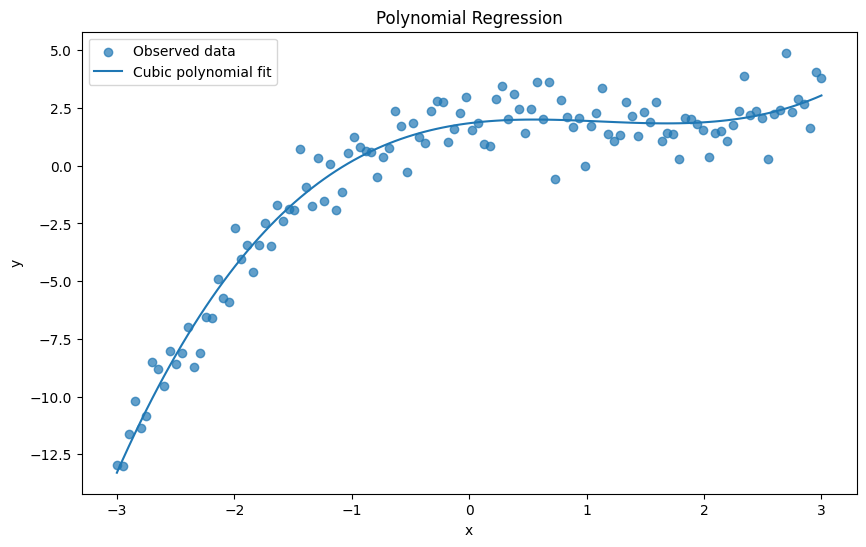

In [19]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_poly = poly.fit_transform(X_raw)

beta_poly = inv(X_poly.T @ X_poly) @ X_poly.T @ y_poly
y_poly_hat = X_poly @ beta_poly

print("Polynomial feature names:", poly.get_feature_names_out())
print("Estimated coefficients:", beta_poly)

plt.scatter(X_raw, y_poly, alpha=0.7, label="Observed data")
plt.plot(X_raw, y_poly_hat, label="Cubic polynomial fit")
plt.title("Polynomial Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## 6.1 Overfitting

A high-degree polynomial can fit the training data extremely well but generalize poorly. This is **overfitting**.

Overfitting means that the model has learned noise in the sample rather than stable structure in the population.

The usual symptom is:

$$
\text{low training error, high test error.}
$$

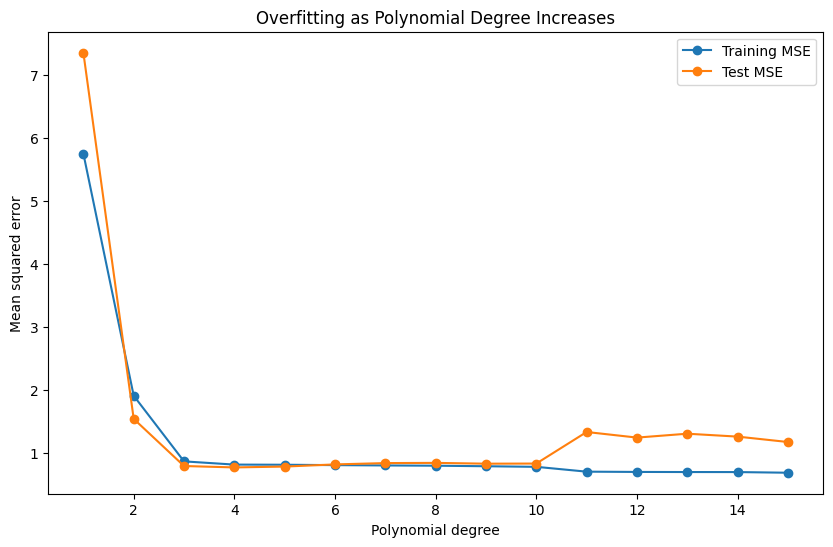

In [20]:
np.random.seed(42)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_poly, test_size=0.30, random_state=42
)

degrees = range(1, 16)
train_mse = []
test_mse = []

for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=d, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train_raw, y_train)
    train_mse.append(mean_squared_error(y_train, model.predict(X_train_raw)))
    test_mse.append(mean_squared_error(y_test, model.predict(X_test_raw)))

plt.plot(list(degrees), train_mse, marker="o", label="Training MSE")
plt.plot(list(degrees), test_mse, marker="o", label="Test MSE")
plt.title("Overfitting as Polynomial Degree Increases")
plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

# 7. Regularization

Regularization modifies least squares by penalizing model complexity.

Ordinary least squares solves

$$
\min_{\beta} \sum_{i=1}^n (y_i - x_i'\beta)^2.
$$

Regularized regression solves a related problem that adds a penalty term to discourage unstable or excessively large coefficients.

The goal is not always to minimize training error. The goal is often to improve out-of-sample prediction.

## 7.1 Ridge regression

Ridge regression solves

$$
\min_{\beta}
\left[
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda \sum_{j=1}^{k}\beta_j^2
\right].
$$

The penalty

$$
\lambda \sum_{j=1}^{k}\beta_j^2
$$

shrinks coefficients toward zero but usually does not set them exactly equal to zero.

The Ridge estimator can be written as

$$
\hat{\beta}_{\text{Ridge}}
=
(X'X + \lambda I)^{-1}X'y.
$$

Ridge is especially useful when regressors are highly correlated or when $X'X$ is nearly singular.

## 7.2 Lasso regression

Lasso regression solves

$$
\min_{\beta}
\left[
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda \sum_{j=1}^{k}|\beta_j|
\right].
$$

The absolute-value penalty can set some coefficients exactly equal to zero. Lasso can therefore perform variable selection.

## 7.3 Elastic Net

Elastic Net combines Ridge and Lasso:

$$
\min_{\beta}
\left[
\sum_{i=1}^n (y_i - x_i'\beta)^2
+
\lambda
\left(
\alpha \sum_{j=1}^{k}|\beta_j|
+
\frac{1-\alpha}{2}\sum_{j=1}^{k}\beta_j^2
\right)
\right].
$$

Here:

- $\lambda$ controls the overall strength of regularization.
- $\alpha = 1$ gives Lasso.
- $\alpha = 0$ gives Ridge-like behavior.
- $0 < \alpha < 1$ mixes both penalties.

In [21]:
# Generate sparse high-dimensional data
np.random.seed(42)

n = 150
p = 20

X_sparse = np.random.normal(0, 1, size=(n, p))
true_coefficients = np.array([1.5, -2.0, 0, 0, 0.8, 0, 0, -1.2, 0, 0,
                              0.5, 0, 0, 0, 0, 0, 0, 0.7, 0, 0])

y_sparse = X_sparse @ true_coefficients + np.random.normal(0, 1.0, n)

X_train, X_test, y_train, y_test = train_test_split(
    X_sparse, y_sparse, test_size=0.30, random_state=42
)

# Standardization is important for regularization because penalties depend on coefficient scale.
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=5.0))
lasso_model = make_pipeline(StandardScaler(), Lasso(alpha=0.10, max_iter=10000))
elastic_model = make_pipeline(StandardScaler(), ElasticNet(alpha=0.10, l1_ratio=0.5, max_iter=10000))

models = {
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Elastic Net": elastic_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print(f"{name}")
    print("  Train MSE:", round(mean_squared_error(y_train, pred_train), 4))
    print("  Test MSE:", round(mean_squared_error(y_test, pred_test), 4))

Ridge
  Train MSE: 0.8381
  Test MSE: 1.3212
Lasso
  Train MSE: 0.9422
  Test MSE: 1.1331
Elastic Net
  Train MSE: 0.9163
  Test MSE: 1.2577


In [22]:
# Extract estimated coefficients
coef_df = pd.DataFrame({
    "Feature": [f"x{j+1}" for j in range(p)],
    "True": true_coefficients,
    "Ridge": ridge_model.named_steps["ridge"].coef_,
    "Lasso": lasso_model.named_steps["lasso"].coef_,
    "Elastic Net": elastic_model.named_steps["elasticnet"].coef_
})

print(coef_df.head(20))

   Feature  True     Ridge     Lasso  Elastic Net
0       x1   1.5  1.357727  1.329070     1.306356
1       x2  -2.0 -2.021268 -2.047210    -1.970495
2       x3   0.0 -0.010078 -0.000000    -0.000000
3       x4   0.0  0.151851  0.013422     0.090321
4       x5   0.8  0.848727  0.789089     0.782518
5       x6   0.0 -0.095445 -0.000000    -0.028678
6       x7   0.0  0.064414  0.000000     0.011149
7       x8  -1.2 -0.903397 -0.889788    -0.871529
8       x9   0.0  0.043183  0.000000     0.000000
9      x10   0.0 -0.043013 -0.000000    -0.000000
10     x11   0.5  0.368095  0.244613     0.290453
11     x12   0.0  0.088289  0.000000     0.046127
12     x13   0.0 -0.103140 -0.000000    -0.058576
13     x14   0.0 -0.062403 -0.000000    -0.000000
14     x15   0.0 -0.057546  0.000000    -0.000000
15     x16   0.0  0.088803  0.000000     0.025748
16     x17   0.0  0.069507  0.000000     0.026608
17     x18   0.7  0.675836  0.636799     0.646822
18     x19   0.0  0.161106  0.078259     0.125060


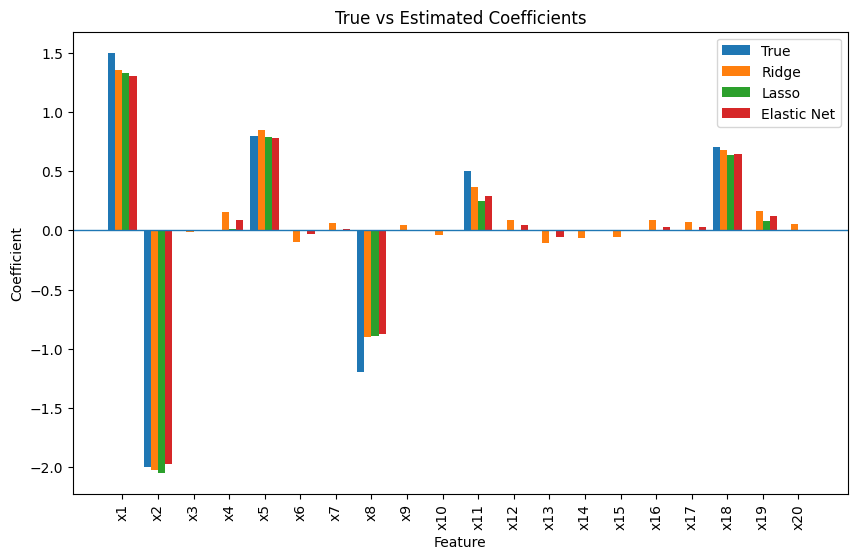

In [23]:
x_positions = np.arange(p)
width = 0.2

plt.bar(x_positions - 1.5*width, coef_df["True"], width=width, label="True")
plt.bar(x_positions - 0.5*width, coef_df["Ridge"], width=width, label="Ridge")
plt.bar(x_positions + 0.5*width, coef_df["Lasso"], width=width, label="Lasso")
plt.bar(x_positions + 1.5*width, coef_df["Elastic Net"], width=width, label="Elastic Net")

plt.axhline(0, linewidth=1)
plt.xticks(x_positions, coef_df["Feature"], rotation=90)
plt.title("True vs Estimated Coefficients")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.legend()
plt.show()

# 8. Coefficient paths

A useful way to understand regularization is to vary the penalty strength and watch the coefficients change.

As $\lambda$ rises:

- Ridge coefficients shrink smoothly toward zero.
- Lasso coefficients often become exactly zero.
- Elastic Net behaves between the two.

In [24]:
alphas = np.logspace(-3, 2, 80)

ridge_coefs = []
lasso_coefs = []

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)

    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

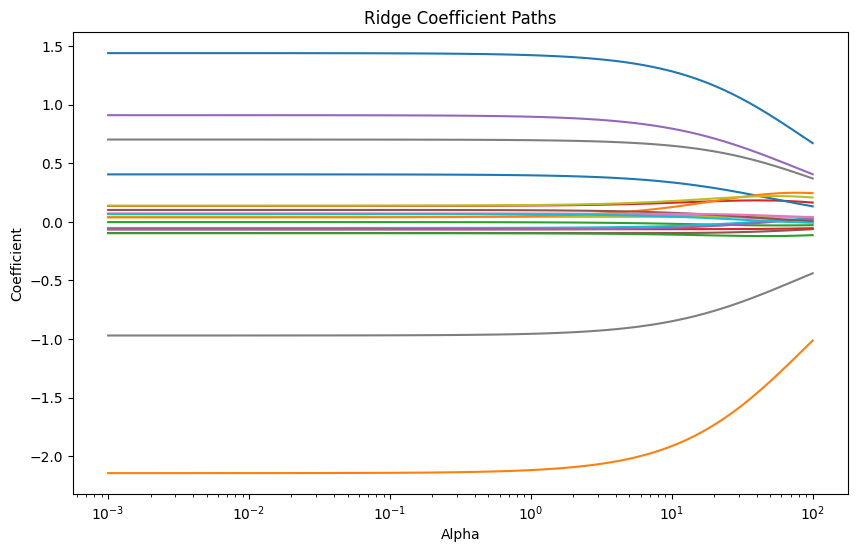

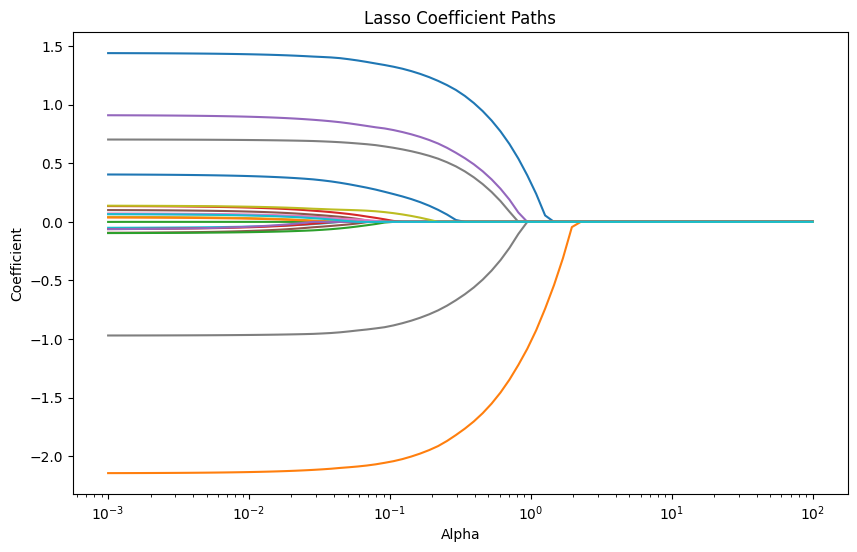

In [25]:
plt.plot(alphas, ridge_coefs)
plt.xscale("log")
plt.title("Ridge Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.show()

plt.plot(alphas, lasso_coefs)
plt.xscale("log")
plt.title("Lasso Coefficient Paths")
plt.xlabel("Alpha")
plt.ylabel("Coefficient")
plt.show()

# 9. Cross-validation

Cross-validation estimates out-of-sample performance by repeatedly splitting the data into training and validation folds.

In $K$-fold cross-validation:

1. Split the data into $K$ folds.
2. Fit the model on $K-1$ folds.
3. Evaluate it on the remaining fold.
4. Repeat until each fold has served as the validation set.
5. Average the validation errors.

Cross-validation is commonly used to choose hyperparameters such as $\lambda$ in Ridge, Lasso, and Elastic Net.

In [26]:
param_grid = {
    "elasticnet__alpha": [0.01, 0.05, 0.10, 0.25, 0.50, 1.00],
    "elasticnet__l1_ratio": [0.10, 0.50, 0.90]
}

elastic_pipeline = make_pipeline(
    StandardScaler(),
    ElasticNet(max_iter=10000, random_state=42)
)

grid_search = GridSearchCV(
    elastic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_
test_predictions = best_model.predict(X_test)

print("\nTest MSE:", mean_squared_error(y_test, test_predictions))
print("Test R^2:", r2_score(y_test, test_predictions))

Best parameters:
{'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.9}

Test MSE: 1.1448599846257965
Test R^2: 0.8906742426205065


In [27]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mean_test_mse"] = -cv_results["mean_test_score"]

summary = cv_results[
    ["param_elasticnet__alpha", "param_elasticnet__l1_ratio", "mean_test_mse"]
].sort_values("mean_test_mse")

print(summary.head(10))

    param_elasticnet__alpha  param_elasticnet__l1_ratio  mean_test_mse
8                      0.10                         0.9       1.317276
5                      0.05                         0.9       1.323891
4                      0.05                         0.5       1.371496
7                      0.10                         0.5       1.390411
2                      0.01                         0.9       1.399187
1                      0.01                         0.5       1.411487
3                      0.05                         0.1       1.417304
0                      0.01                         0.1       1.424875
6                      0.10                         0.1       1.470903
11                     0.25                         0.9       1.654583


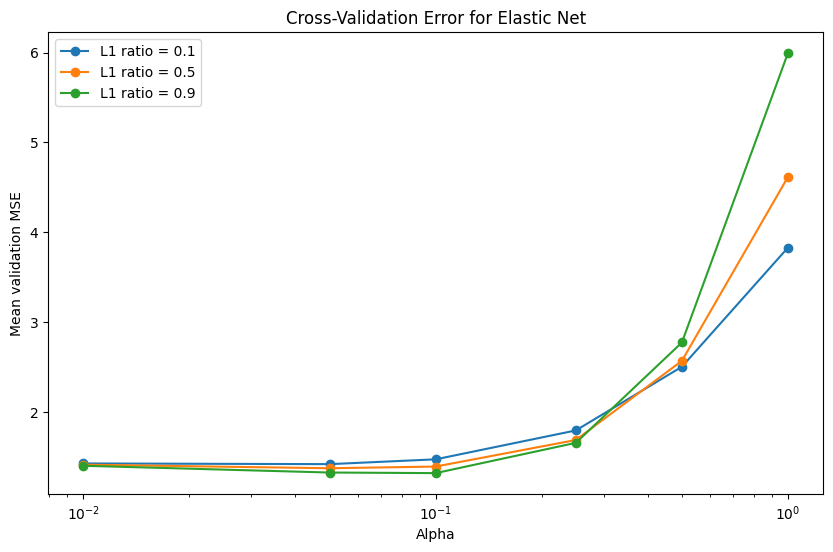

In [28]:
for l1_ratio in sorted(cv_results["param_elasticnet__l1_ratio"].unique()):
    subset = cv_results[cv_results["param_elasticnet__l1_ratio"] == l1_ratio]
    subset = subset.sort_values("param_elasticnet__alpha")
    plt.plot(
        subset["param_elasticnet__alpha"].astype(float),
        subset["mean_test_mse"],
        marker="o",
        label=f"L1 ratio = {l1_ratio}"
    )

plt.xscale("log")
plt.title("Cross-Validation Error for Elastic Net")
plt.xlabel("Alpha")
plt.ylabel("Mean validation MSE")
plt.legend()
plt.show()

# 10. Summary: why linear algebra matters

Linear algebra lets us write and solve empirical models compactly.

The central objects in this lecture were:

1. **Vectors**, which represent quantities, prices, returns, coefficients, or residuals.
2. **Matrices**, which represent datasets, transformations, systems, and covariance structures.
3. **Systems of equations**, written as

$$
Ax = b.
$$

4. **Least squares**, written as

$$
\min_{\beta} (y - X\beta)'(y - X\beta).
$$

5. **OLS**, with solution

$$
\hat{\beta} = (X'X)^{-1}X'y.
$$

6. **Projection geometry**, where the fitted values are the projection of $y$ onto the column space of $X$.
7. **Regularization**, which modifies least squares to improve out-of-sample performance.

The same matrix language appears throughout finance, accounting, economics, econometrics, and machine learning. It is the common structure underneath portfolio optimization, risk models, regressions, factor models, time-series models, and predictive analytics.

## Practice problems

1. Create a $3 \times 3$ matrix and check whether it is invertible.
2. Simulate a two-asset portfolio and compute expected return and variance using matrix notation.
3. Estimate a simple regression manually using

$$
\hat{\beta} = (X'X)^{-1}X'y.
$$

4. Verify that $X'\hat{e}=0$ in your regression.
5. Fit polynomial regressions of degrees 1 through 10 and compare training and test errors.
6. Fit Ridge, Lasso, and Elastic Net models to the same data and compare coefficient estimates.
7. Use cross-validation to choose the Elastic Net penalty parameters.